# E-Commerce Sales Analysis: Customer Segments, Cohorts, Seasonality & Product Performance

**Goal:** Understand who our best customers are, how well we retain them, when
demand peaks, and which products actually drive profit — then turn each
finding into a concrete recommendation.

**Dataset:** [Sample Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)
— a real-world US retail dataset, 9,994 order line items across 5,009 orders
and 793 customers, January 2014 – December 2017. Each row is a product line
item with Order/Ship info, Customer, Region/Segment, Category/Sub-Category,
Sales, Quantity, Discount, and Profit.

**Sections**
1. Load, reshape & clean data
2. RFM analysis → customer segments
3. Cohort retention analysis
4. Seasonal & time trends
5. Product performance (Pareto + profit analysis)
6. Business recommendations


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load, reshape & clean data

The raw file is one row per **line item**, with order- and customer-level
fields repeated on every row. We reshape it into three tidy tables
(`customers`, `orders`, `items`) so each grain of analysis is unambiguous.

In [3]:
raw = pd.read_csv("../data/superstore_raw.csv", encoding="latin-1", parse_dates=["Order Date", "Ship Date"])
print(f"Raw rows: {raw.shape[0]:,}, columns: {raw.shape[1]}")
raw.head(3)


Raw rows: 9,994, columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87


In [4]:
# --- Data quality checks on the raw file ---
missing = raw.isna().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing if len(missing) else "None")
print("\nDuplicate rows:", raw.duplicated().sum())
print("Negative Sales:", (raw["Sales"] < 0).sum())
print("Date range:", raw["Order Date"].min().date(), "to", raw["Order Date"].max().date())
print("Unique customers:", raw["Customer ID"].nunique())
print("Unique orders:", raw["Order ID"].nunique())


Missing values per column:
None

Duplicate rows: 0
Negative Sales: 0
Date range: 2014-01-03 to 2017-12-30
Unique customers: 793
Unique orders: 5009


In [5]:
# --- Reshape into item / order / customer tables ---
items = raw.rename(columns={
    "Order ID": "order_id", "Customer ID": "customer_id", "Order Date": "order_date",
    "Category": "category", "Sub-Category": "sub_category",
    "Quantity": "quantity", "Discount": "discount", "Sales": "sales", "Profit": "profit",
})[["order_id", "customer_id", "order_date", "category", "sub_category",
    "quantity", "discount", "sales", "profit"]].copy()
items["item_id"] = items.index.astype(str)

orders = items.groupby(["order_id", "customer_id", "order_date"], as_index=False).agg(
    sales=("sales", "sum"), profit=("profit", "sum"))
order_meta = raw[["Order ID", "Region", "Segment"]].drop_duplicates(subset="Order ID")
orders = orders.merge(order_meta, left_on="order_id", right_on="Order ID").drop(columns="Order ID")
orders = orders.rename(columns={"Region": "region", "Segment": "segment"})

customers = raw.groupby("Customer ID", as_index=False).agg(
    segment=("Segment", "first"),
    region=("Region", "first"),
    first_purchase_date=("Order Date", "min"),
)
customers = customers.rename(columns={"Customer ID": "customer_id"})

print(f"customers: {customers.shape}, orders: {orders.shape}, items: {items.shape}")
orders.head(3)


customers: (793, 4), orders: (5009, 7), items: (9994, 10)


,order_id,customer_id,order_date,sales,profit,region,segment
0,CA-2014-100006,DK-13375,2014-09-07,377.97,109.61,East,Consumer
1,CA-2014-100090,EB-13705,2014-07-08,699.19,-19.09,West,Corporate
2,CA-2014-100293,NF-18475,2014-03-14,91.06,31.87,South,Home Office


No missing values or duplicate rows in the source file. One thing worth flagging for the write-up: **~19% of line items carry a negative profit** (heavy discounting on Furniture/Technology) — that shows up clearly in the discount-vs-margin analysis in Section 5, and it's real, not a data quality issue.

In [6]:
neg_profit_pct = (items["profit"] < 0).mean() * 100
print(f"Line items with negative profit: {neg_profit_pct:.1f}%")


Line items with negative profit: 18.7%


## 2. RFM Analysis → Customer Segments

**Recency** (days since last order), **Frequency** (number of orders), and
**Monetary** (total spend) are scored 1–4 (quartiles) and combined into an
RFM score, then mapped to human-readable segments.

In [7]:
snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)

rfm = orders.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("sales", "sum"),
).reset_index()

rfm = rfm.merge(customers[["customer_id", "segment", "region"]], on="customer_id")
rfm.describe()


,recency,frequency,monetary
count,793.00,793.00,793.00
mean,147.80,6.32,"2,896.85"
std,186.21,2.55,"2,628.67"
min,1.00,1.00,4.83
25%,31.00,5.00,"1,146.05"
50%,76.00,6.00,"2,256.39"
75%,184.00,8.00,"3,785.28"
max,"1,166.00",17.00,"25,043.05"


In [8]:
rfm["R"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]

def label_segment(row):
    if row["RFM_score"] >= 10:
        return "Champions"
    elif row["RFM_score"] >= 8:
        return "Loyal Customers"
    elif row["RFM_score"] >= 6:
        return "Potential Loyalists"
    elif row["R"] <= 2 and row["F"] <= 2:
        return "At Risk"
    else:
        return "Lost / Hibernating"

rfm["rfm_segment"] = rfm.apply(label_segment, axis=1)

segment_summary = rfm.groupby("rfm_segment").agg(
    customers=("customer_id", "count"),
    total_revenue=("monetary", "sum"),
    avg_recency_days=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
).sort_values("total_revenue", ascending=False)
segment_summary["pct_of_customers"] = (segment_summary["customers"] / len(rfm) * 100).round(1)
segment_summary["pct_of_revenue"] = (segment_summary["total_revenue"] / rfm["monetary"].sum() * 100).round(1)
segment_summary


,customers,total_revenue,avg_recency_days,avg_frequency,pct_of_customers,pct_of_revenue
rfm_segment,,,,,,
Champions,193,"921,597.32",36.78,8.95,24.30,40.10
Loyal Customers,222,"816,229.58",92.60,7.08,28.00,35.50
Potential Loyalists,182,"371,743.71",150.07,5.36,23.00,16.20
At Risk,169,"170,511.39",353.22,3.75,21.30,7.40
Lost / Hibernating,27,"17,118.86",94.22,3.78,3.40,0.70


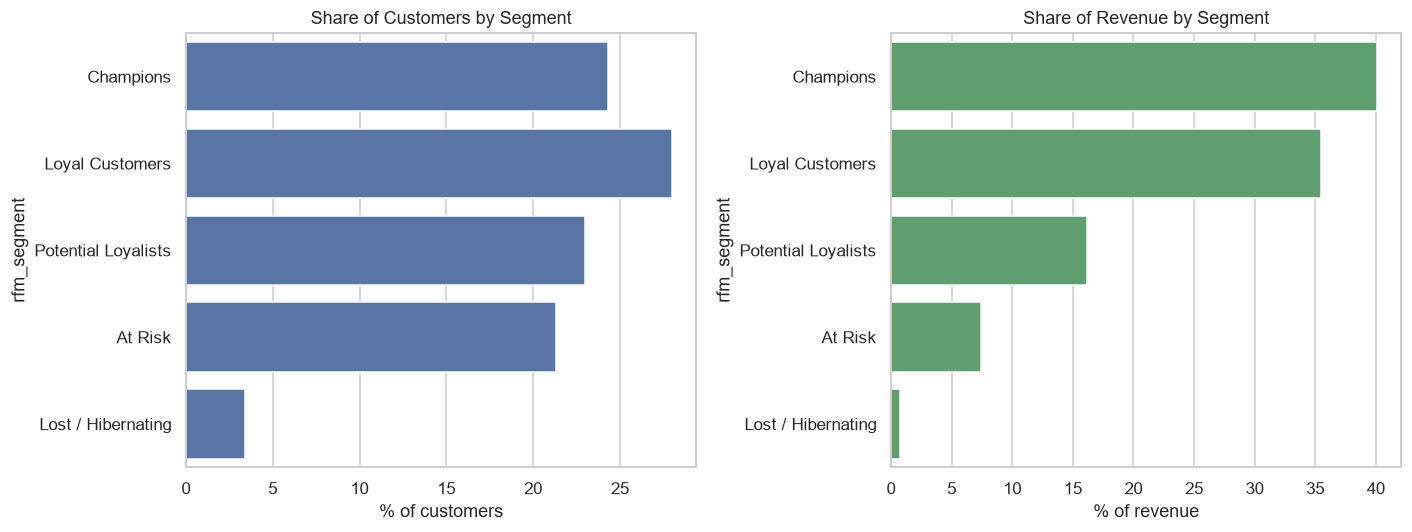

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = segment_summary.index
sns.barplot(x=segment_summary["pct_of_customers"], y=order, ax=axes[0], color="#4C72B0")
axes[0].set_title("Share of Customers by Segment")
axes[0].set_xlabel("% of customers")
sns.barplot(x=segment_summary["pct_of_revenue"], y=order, ax=axes[1], color="#55A868")
axes[1].set_title("Share of Revenue by Segment")
axes[1].set_xlabel("% of revenue")
plt.tight_layout()
plt.savefig("../charts/rfm_segments.png", bbox_inches="tight")
plt.show()


**Reading this chart:** compare the two bars for each segment. If a segment's revenue bar is much bigger than its customer-count bar, those are the highest-value customers relative to their numbers.

In [10]:
X = StandardScaler().fit_transform(rfm[["recency", "frequency", "monetary"]])
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm["kmeans_cluster"] = kmeans.fit_predict(X)

cluster_profile = rfm.groupby("kmeans_cluster")[["recency", "frequency", "monetary"]].mean().round(1)
cluster_profile["customers"] = rfm.groupby("kmeans_cluster").size()
cluster_profile.sort_values("monetary", ascending=False)


,recency,frequency,monetary,customers
kmeans_cluster,,,,
2,142.70,7.90,"10,289.60",48
1,65.50,9.90,"4,142.30",143
4,77.20,7.00,"2,838.20",262
3,562.20,3.70,"1,484.70",95
0,111.70,4.30,"1,331.80",245


The K-Means clusters give an unsupervised cross-check on the manual RFM buckets — useful to mention in an interview as evidence the segmentation isn't arbitrary.

## 3. Cohort Retention Analysis

Group customers by the month of their **first purchase**, then track what %
of each cohort is still ordering in each subsequent month.

In [11]:
orders_c = orders.merge(customers[["customer_id", "first_purchase_date"]], on="customer_id")
orders_c["cohort_month"] = orders_c["first_purchase_date"].dt.to_period("M")
orders_c["order_month"] = orders_c["order_date"].dt.to_period("M")
orders_c["period_number"] = (orders_c["order_month"] - orders_c["cohort_month"]).apply(lambda x: x.n)

cohort_data = orders_c.groupby(["cohort_month", "period_number"])["customer_id"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="period_number", values="customer_id")

cohort_size = cohort_pivot.iloc[:, 0]
retention = (cohort_pivot.divide(cohort_size, axis=0) * 100).round(1)
retention.iloc[:12, :13]


period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2014-01,100.00,9.40,NaN,6.20,6.20,NaN,6.20,12.50,15.60,9.40,21.90,15.60,9.40
2014-02,100.00,16.70,8.30,4.20,NaN,8.30,8.30,12.50,12.50,16.70,16.70,4.20,NaN
2014-03,100.00,6.20,3.10,12.30,10.80,NaN,10.80,7.70,12.30,9.20,1.50,3.10,9.20
2014-04,100.00,10.70,3.60,7.10,5.40,14.30,10.70,16.10,14.30,1.80,7.10,8.90,14.30
2014-05,100.00,8.90,8.90,7.10,17.90,3.60,21.40,17.90,7.10,5.40,7.10,12.50,3.60
2014-06,100.00,2.10,4.20,8.30,4.20,18.80,16.70,2.10,8.30,12.50,10.40,10.40,6.20
2014-07,100.00,13.60,11.40,NaN,11.40,18.20,4.50,NaN,18.20,4.50,15.90,15.90,11.40
2014-08,100.00,16.30,6.10,22.40,10.20,6.10,8.20,4.10,8.20,6.10,10.20,12.20,4.10
2014-09,100.00,13.20,13.20,16.20,1.50,2.90,13.20,14.70,13.20,2.90,8.80,11.80,17.60


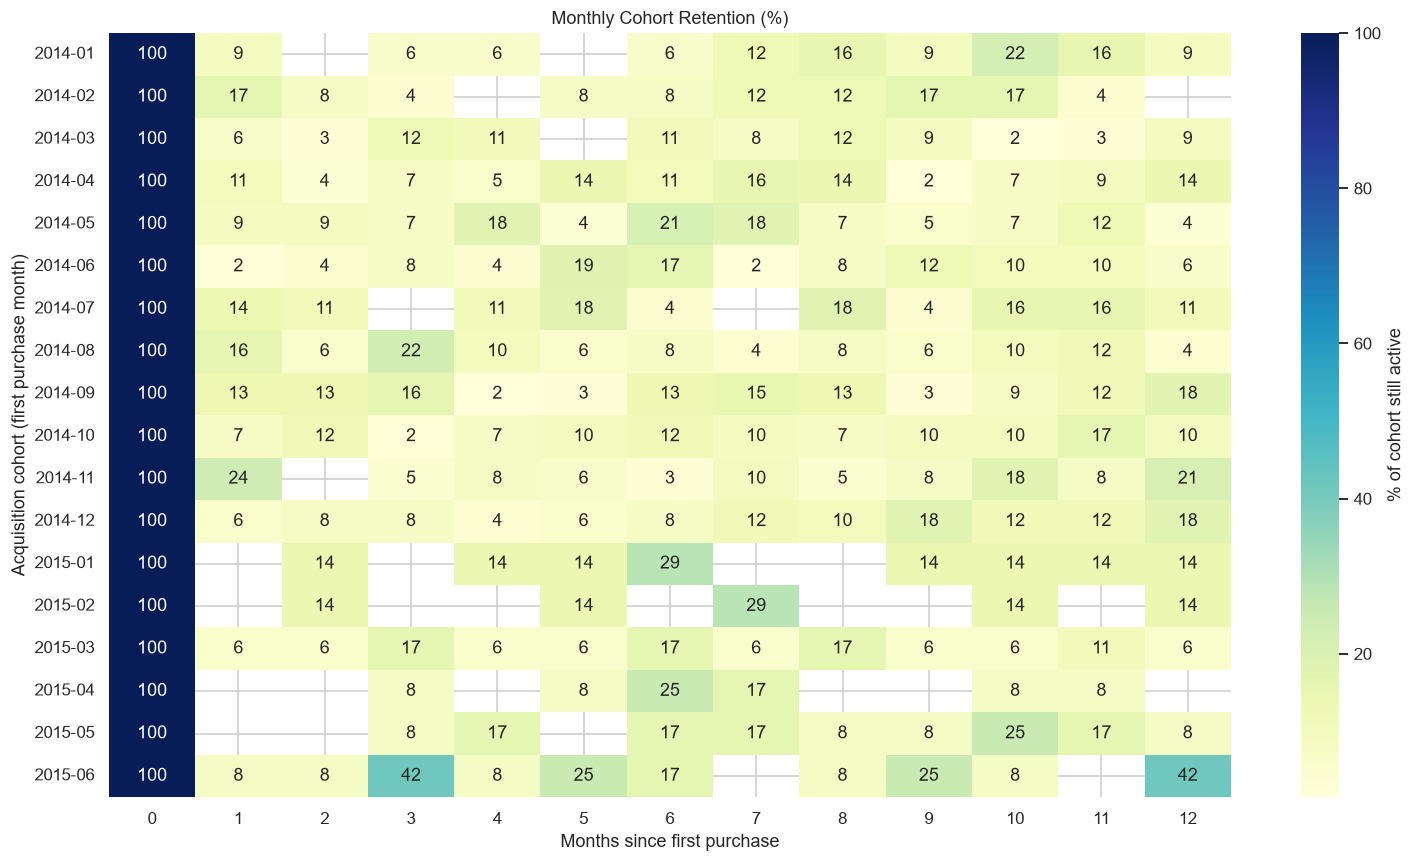

In [12]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention.iloc[:18, :13], annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% of cohort still active"})
plt.title("Monthly Cohort Retention (%)")
plt.xlabel("Months since first purchase")
plt.ylabel("Acquisition cohort (first purchase month)")
plt.tight_layout()
plt.savefig("../charts/cohort_retention.png", bbox_inches="tight")
plt.show()


In [13]:
avg_retention_by_month = retention.mean(axis=0)
print("Average retention by months-since-acquisition:")
print(avg_retention_by_month.head(13).round(1))


Average retention by months-since-acquisition:
period_number
0    100.00
1     12.10
2     19.10
3     15.00
4     15.00
5     16.20
6     17.90
7     15.10
8     15.60
9     16.50
10    19.10
11    18.30
12    18.90
dtype: float64


**Reading this heatmap:** month 0 is always 100% by definition. Watch the
drop from month 0 to month 1 — that's the steepest cliff and usually the
highest-leverage place to intervene.

## 4. Seasonal & Time Trends

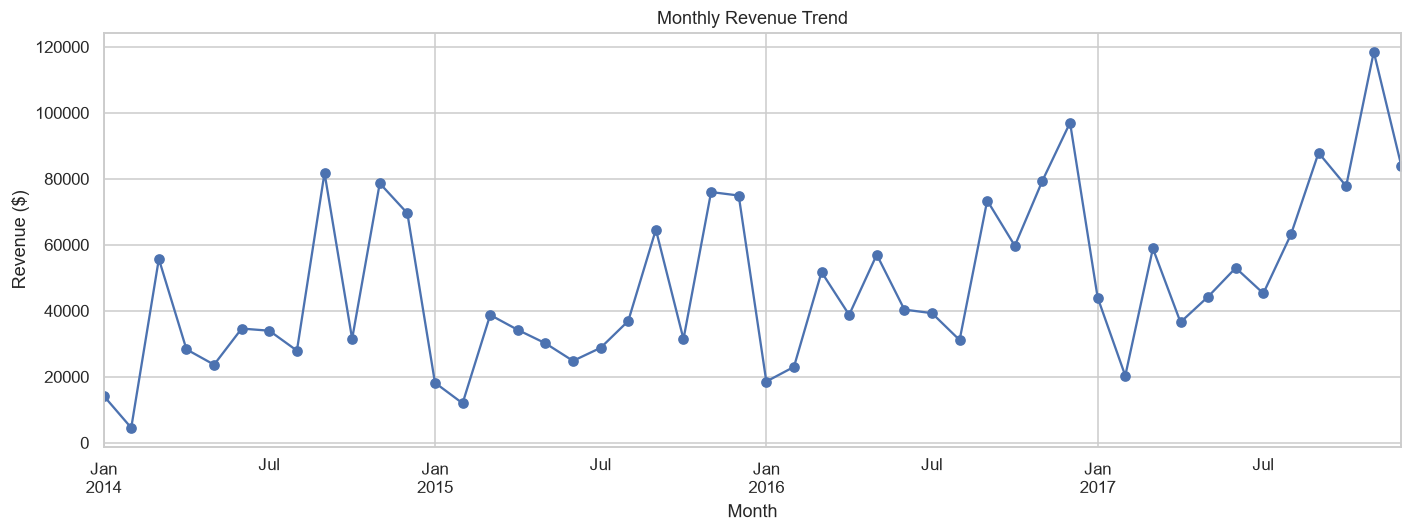

In [14]:
monthly = orders.set_index("order_date").resample("MS")["sales"].sum()
plt.figure(figsize=(13, 5))
monthly.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue ($)")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("../charts/monthly_revenue.png", bbox_inches="tight")
plt.show()


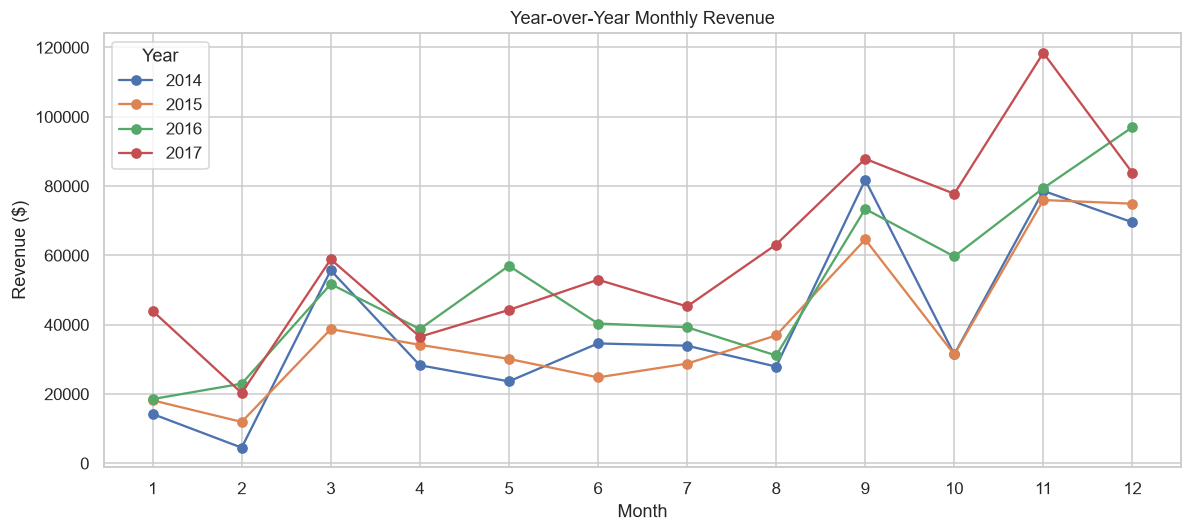

In [15]:
orders["year"] = orders["order_date"].dt.year
orders["month"] = orders["order_date"].dt.month
yoy = orders.groupby(["year", "month"])["sales"].sum().unstack(level=0)

plt.figure(figsize=(11, 5))
for year in yoy.columns:
    plt.plot(yoy.index, yoy[year], marker="o", label=str(year))
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.title("Year-over-Year Monthly Revenue")
plt.legend(title="Year")
plt.tight_layout()
plt.savefig("../charts/yoy_revenue.png", bbox_inches="tight")
plt.show()


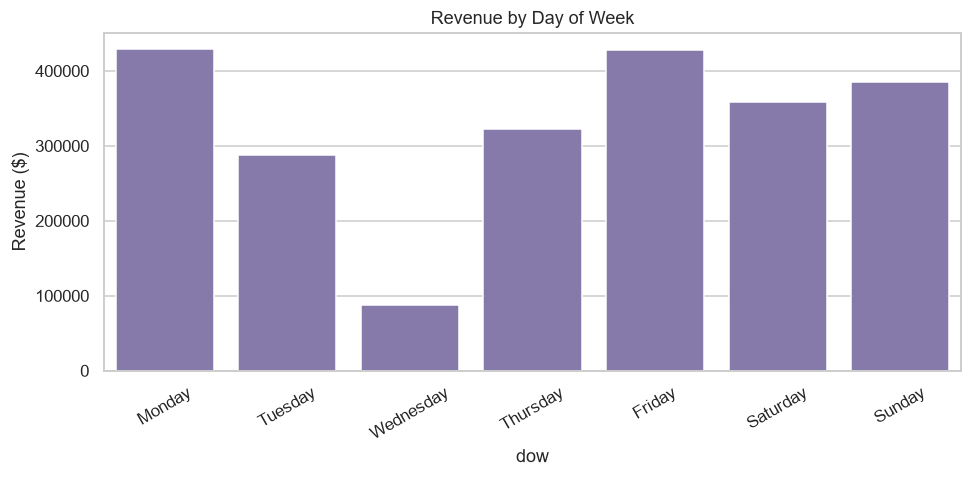

In [16]:
orders["dow"] = orders["order_date"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_sales = orders.groupby("dow")["sales"].sum().reindex(dow_order)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=dow_sales.index, y=dow_sales.values, color="#8172B2")
plt.title("Revenue by Day of Week")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../charts/dow_revenue.png", bbox_inches="tight")
plt.show()


**What to look for:** an overall growth trend across 2014-2017, a
recurring Q4 seasonal peak (common in US retail ahead of the holidays), and
whether ordering is weekday-heavy (consistent with the Corporate/Home
Office segments in this B2B-leaning dataset).

## 5. Product Performance

Two questions: (1) do a small share of sub-categories drive most of the
revenue (Pareto/80-20)? and (2) is discounting helping or quietly
destroying margin?

In [17]:
subcat_perf = items.groupby("sub_category").agg(
    revenue=("sales", "sum"), profit=("profit", "sum"), units=("quantity", "sum"),
).sort_values("revenue", ascending=False)
subcat_perf["profit_margin_pct"] = (subcat_perf["profit"] / subcat_perf["revenue"] * 100).round(1)
subcat_perf["cum_pct_revenue"] = (subcat_perf["revenue"].cumsum() / subcat_perf["revenue"].sum() * 100).round(1)
subcat_perf


,revenue,profit,units,profit_margin_pct,cum_pct_revenue
sub_category,,,,,
Phones,"330,007.05","44,515.73",3289,13.50,14.40
Chairs,"328,449.10","26,590.17",2356,8.10,28.70
Storage,"223,843.61","21,278.83",3158,9.50,38.40
Tables,"206,965.53","-17,725.48",1241,-8.60,47.40
Binders,"203,412.73","30,221.76",5974,14.90,56.30
Machines,"189,238.63","3,384.76",440,1.80,64.50
Accessories,"167,380.32","41,936.64",2976,25.10,71.80
Copiers,"149,528.03","55,617.82",234,37.20,78.30
Bookcases,"114,880.00","-3,472.56",868,-3.00,83.30


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14076\4077763305.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(subcat_perf.index, rotation=40, ha="right")


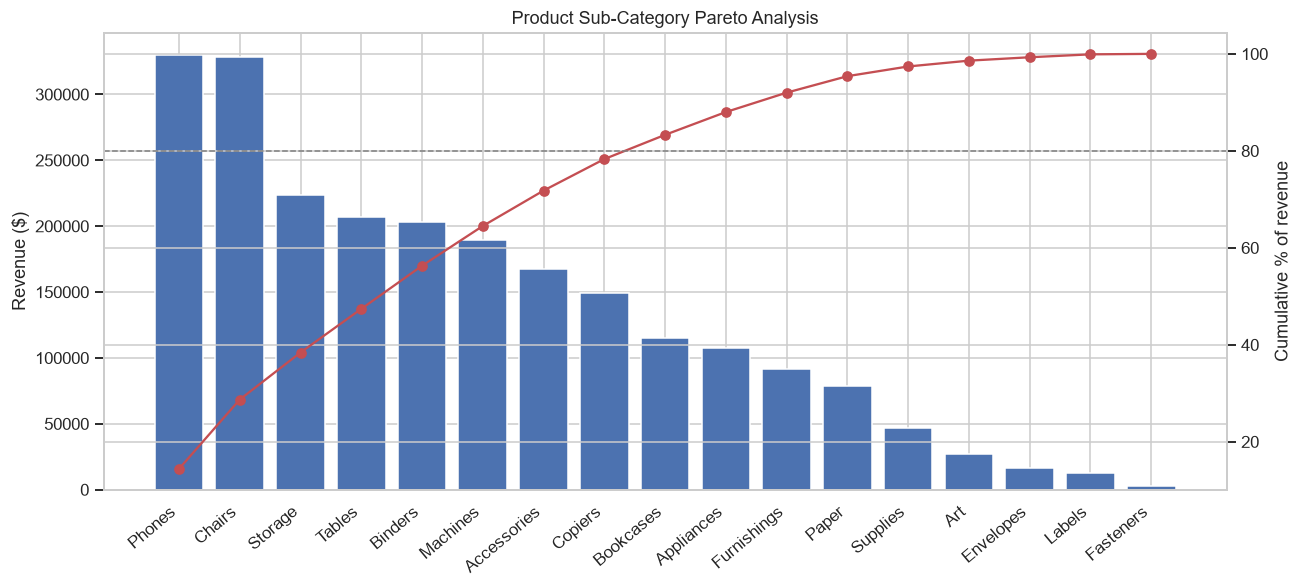

9 of 17 sub-categories generate ~80% of revenue.


In [18]:
fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax1.bar(subcat_perf.index, subcat_perf["revenue"], color="#4C72B0")
ax1.set_ylabel("Revenue ($)")
ax1.set_xticklabels(subcat_perf.index, rotation=40, ha="right")
ax2 = ax1.twinx()
ax2.plot(subcat_perf.index, subcat_perf["cum_pct_revenue"], color="#C44E52", marker="o")
ax2.set_ylabel("Cumulative % of revenue")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
plt.title("Product Sub-Category Pareto Analysis")
plt.tight_layout()
plt.savefig("../charts/pareto_subcategory.png", bbox_inches="tight")
plt.show()

n_subcats_for_80pct = (subcat_perf["cum_pct_revenue"] <= 80).sum() + 1
print(f"{n_subcats_for_80pct} of {len(subcat_perf)} sub-categories generate ~80% of revenue.")


In [19]:
items["discount_bucket"] = pd.cut(items["discount"], bins=[-0.01, 0, 0.1, 0.2, 0.3, 1.0],
                                    labels=["0%", "1-10%", "11-20%", "21-30%", "30%+"])
disc_profit = items.groupby("discount_bucket", observed=True).agg(
    orders=("item_id", "count"), revenue=("sales", "sum"), profit=("profit", "sum"),
)
disc_profit["margin_pct"] = (disc_profit["profit"] / disc_profit["revenue"] * 100).round(1)
disc_profit


,orders,revenue,profit,margin_pct
discount_bucket,,,,
0%,4798,"1,087,908.47","320,987.60",29.50
1-10%,94,"54,369.35","9,029.18",16.60
11-20%,3709,"792,152.89","91,756.30",11.60
21-30%,227,"103,226.65","-10,369.28",-10.00
30%+,1166,"259,543.49","-125,006.78",-48.20


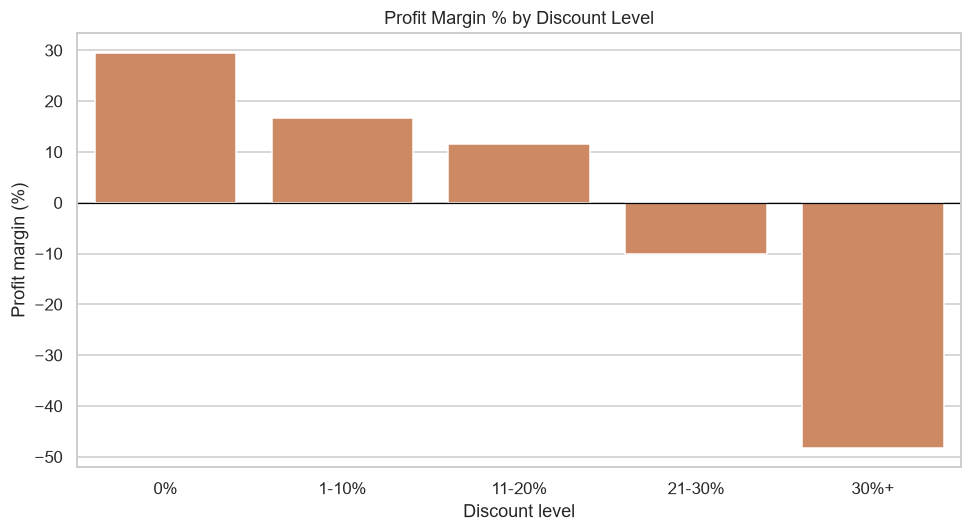

In [23]:
plt.figure(figsize=(9, 5))
sns.barplot(x=disc_profit.index, y=disc_profit["margin_pct"], color="#DD8452")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Profit Margin % by Discount Level")
plt.ylabel("Profit margin (%)")
plt.xlabel("Discount level")
plt.tight_layout()
plt.savefig("../charts/discount_margin.png", bbox_inches="tight")
plt.show()


**What to look for:** if margin turns negative at high discount tiers, those discounts are likely destroying value rather than driving profitable volume.

## 6. Business Recommendations

In [22]:
top_seg = segment_summary.index[0]
top_seg_rev_pct = segment_summary.loc[top_seg, "pct_of_revenue"]
top_seg_cust_pct = segment_summary.loc[top_seg, "pct_of_customers"]
at_risk_rev = segment_summary.loc["At Risk", "total_revenue"] if "At Risk" in segment_summary.index else 0
at_risk_cust = segment_summary.loc["At Risk", "customers"] if "At Risk" in segment_summary.index else 0
m1_retention = avg_retention_by_month.get(1, np.nan)
worst_margin_bucket = disc_profit["margin_pct"].idxmin()
worst_margin_val = disc_profit["margin_pct"].min()

print(f"'{top_seg}' = {top_seg_cust_pct}% of customers but {top_seg_rev_pct}% of revenue.")
print(f"'At Risk' segment: {at_risk_cust} customers, ${at_risk_rev:,.0f} historical revenue.")
print(f"Month-1 retention (avg across cohorts): {m1_retention:.1f}%.")
print(f"Top {n_subcats_for_80pct} of {len(subcat_perf)} sub-categories drive ~80% of revenue.")
print(f"Worst-margin discount tier: {worst_margin_bucket} at {worst_margin_val:.1f}% margin.")


'Champions' = 24.3% of customers but 40.1% of revenue.
'At Risk' segment: 169 customers, $170,511 historical revenue.
Month-1 retention (avg across cohorts): 12.1%.
Top 9 of 17 sub-categories drive ~80% of revenue.
Worst-margin discount tier: 30%+ at -48.2% margin.


**1. Protect and grow the Champions segment.**
A small share of customers generates a disproportionate share of revenue.
Put them on a VIP track — early access, a dedicated account contact for
Corporate/Home Office accounts, or a loyalty tier.

**2. Launch a win-back campaign for "At Risk" customers.**
Real historical spend, gone quiet. A targeted incentive is usually
profitable here since acquisition cost is already sunk.

**3. Fix the month-0 → month-1 retention cliff.**
The steepest drop in the cohort heatmap happens right after the first
purchase — a second-purchase incentive sent right after checkout directly
targets this window.

**4. Double down on top revenue sub-categories, but audit their margins.**
A small number of sub-categories drive most revenue — concentrate
merchandising and marketing spend there, but cross-check against margin
first (see #5 — Technology/Furniture are heavily discounted).

**5. Cap or restructure deep discounting.**
Margin compresses sharply — and can turn negative — at the highest discount
tiers, concentrated in Furniture and Technology. Consider a discount
ceiling, or reserve deep discounts for clearing aged inventory rather than
a routine sales lever.
